# ML Analysis: Predicting Salaries in the AI & Data Science Job Market

This notebook applies machine learning models to predict salary levels based on job-related features such as experience level, skills, company size, and work type.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("AI_Job_Market_Trends_2026.csv")
df.head()

,job_id,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings
0,1,AI Engineer,Startup,Retail,Canada,Remote,Senior,2,Master,0,0,0,1,0,158322,6,2024,Low,4
1,2,Machine Learning Engineer,MNC,Technology,Australia,Hybrid,Mid,0,Bachelor,1,1,1,0,1,163666,11,2026,High,9
2,3,Machine Learning Engineer,MNC,Technology,Germany,Onsite,Mid,14,Master,1,0,1,0,1,158556,3,2026,High,9
3,4,Business Analyst,Startup,Healthcare,Germany,Remote,Mid,9,Master,0,1,0,1,1,95775,3,2025,High,7
4,5,Data Scientist,MNC,Healthcare,Germany,Hybrid,Mid,5,Master,1,1,1,0,0,111873,12,2021,Low,2


# Data Preprocessing

Categorical variables are encoded into numerical values to make them suitable for machine learning models.

In [8]:
# Encode categorical variables
le = LabelEncoder()

cat_cols = ["job_title", "company_size", "company_industry",
            "country", "remote_type", "experience_level",
            "education_level", "hiring_urgency"]

df_ml = df.copy()
for col in cat_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

# Define features and target
features = ["experience_level", "years_experience", "company_size",
            "remote_type", "education_level", "skills_python",
            "skills_sql", "skills_ml", "skills_deep_learning", "skills_cloud"]

X = df_ml[features]
y = df_ml["salary"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (8276, 10)
Test set size: (2069, 10)


## Model 1: Linear Regression

Linear Regression is used as a baseline model to predict salary based on job-related features.


In [9]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results:")
print(f"  RMSE: {rmse_lr:.2f}")
print(f"  R² Score: {r2_lr:.4f}")

Linear Regression Results:
  RMSE: 20900.96
  R² Score: 0.5613


## Model 2: Random Forest

Random Forest is an ensemble learning method that builds multiple decision trees to improve prediction accuracy.

In [10]:
# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results:")
print(f"  RMSE: {rmse_rf:.2f}")
print(f"  R² Score: {r2_rf:.4f}")

Random Forest Results:
  RMSE: 21024.15
  R² Score: 0.5561


## Model Comparison

The two models are compared based on RMSE and R² scores to evaluate their performance.

               Model          RMSE  R² Score
0  Linear Regression  20900.962565  0.561261
1      Random Forest  21024.151283  0.556074


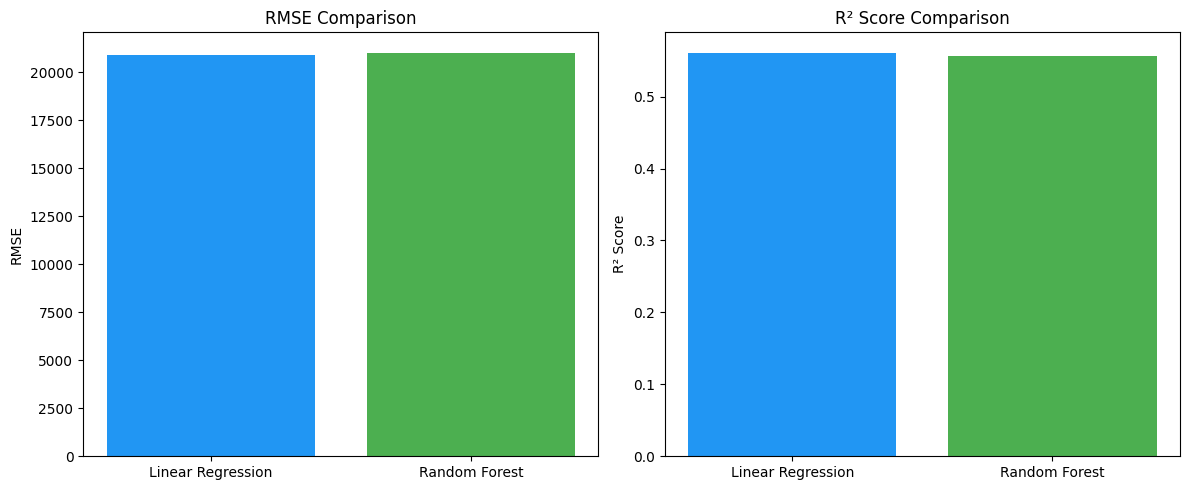

In [11]:
# Model Comparison
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "RMSE": [rmse_lr, rmse_rf],
    "R² Score": [r2_lr, r2_rf]
})

print(results)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(results["Model"], results["RMSE"], color=["#2196F3", "#4CAF50"])
axes[0].set_title("RMSE Comparison")
axes[0].set_ylabel("RMSE")

axes[1].bar(results["Model"], results["R² Score"], color=["#2196F3", "#4CAF50"])
axes[1].set_title("R² Score Comparison")
axes[1].set_ylabel("R² Score")

plt.tight_layout()
plt.show()

## Feature Importance

This section identifies which features have the most influence on salary prediction according to the Random Forest model.

/tmp/ipykernel_4199/2120913960.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance.values, y=importance.index, palette="Blues_r")


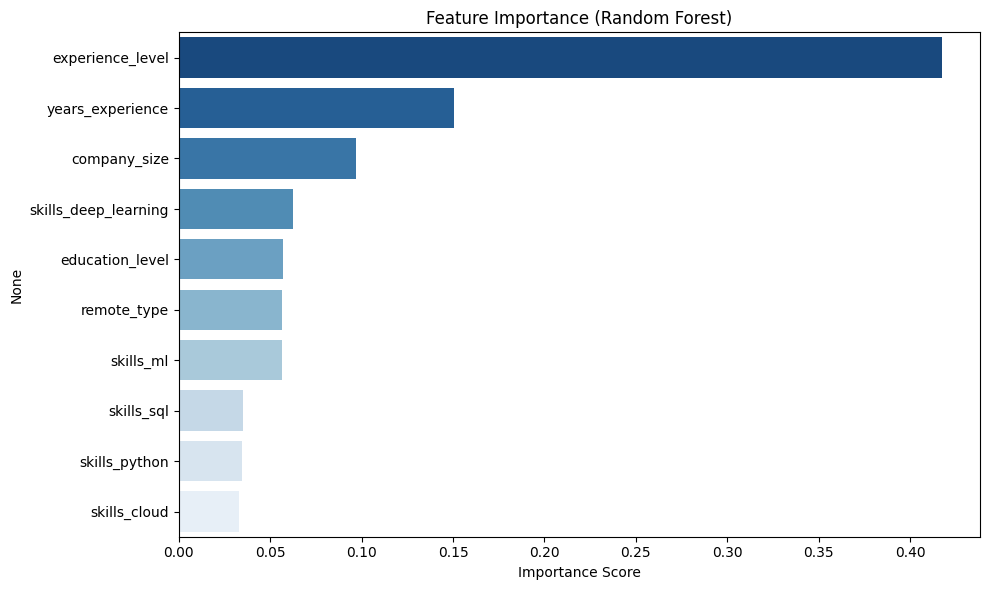

In [12]:
# Feature Importance
importance = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importance.values, y=importance.index, palette="Blues_r")
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

## Conclusion

Both models achieved similar performance, with Linear Regression slightly outperforming Random Forest.

| Model | RMSE | R² Score |
|---|---|---|
| Linear Regression | 20900.96 | 0.5613 |
| Random Forest | 21024.15 | 0.5561 |

The feature importance analysis confirms that **experience_level** is by far the most influential factor in predicting salary, followed by years_experience and company_size. This is consistent with the hypothesis testing results from the EDA phase.

Technical skills such as Python, SQL, and cloud computing have relatively lower importance scores, suggesting that experience and seniority matter more than individual skill sets when it comes to salary determination.